install, import, config

In [1]:
from google.colab import drive
drive.mount("/content/drive")

!ls -lh "/content/drive/MyDrive/vtac.zip"
!cp "/content/drive/MyDrive/vtac.zip" "/content/vtac.zip"

!ls -lh "/content/vtac.zip"
!file "/content/vtac.zip"

!mkdir -p /content/vtac_unzipped
!unzip -q "/content/vtac.zip" -d /content/vtac_unzipped

Mounted at /content/drive
-rw------- 1 root root 2.7G May 26 08:14 /content/drive/MyDrive/vtac.zip
-rw------- 1 root root 2.7G May 26 12:14 /content/vtac.zip
/content/vtac.zip: Zip archive data, at least v2.0 to extract, compression method=deflate


In [7]:
!pip install -q "wfdb==4.1.2" scipy scikit-learn tqdm

from pathlib import Path
from fractions import Fraction
import warnings

import numpy as np
import pandas as pd
import torch
import wfdb

from tqdm.auto import tqdm
from scipy.signal import butter, buttord, sosfiltfilt, iirnotch, filtfilt, resample_poly
from sklearn.model_selection import train_test_split

print("pandas:", pd.__version__)
print("wfdb:", wfdb.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.0/160.0 kB 8.7 MB/s eta 0:00:00
pandas: 3.0.3
wfdb: 4.3.1


In [8]:
# ============================================================
# Locate VTaC root
# ============================================================

UNZIP_ROOT = Path("/content/vtac_unzipped")

label_candidates = list(UNZIP_ROOT.rglob("event_labels.csv"))
if len(label_candidates) == 0:
    raise FileNotFoundError("event_labels.csv not found under /content/vtac_unzipped")

LABEL_CSV = label_candidates[0]
ROOT = LABEL_CSV.parent

SPLIT_CSV = ROOT / "benchmark_data_split.csv"
WAVEFORM_DIR = ROOT / "waveforms"

if not WAVEFORM_DIR.exists():
    waveform_candidates = [p for p in ROOT.rglob("waveforms") if p.is_dir()]
    if len(waveform_candidates) == 0:
        raise FileNotFoundError("waveforms folder not found")
    WAVEFORM_DIR = waveform_candidates[0]

print("ROOT:", ROOT)
print("LABEL_CSV:", LABEL_CSV)
print("SPLIT_CSV:", SPLIT_CSV, "exists:", SPLIT_CSV.exists())
print("WAVEFORM_DIR:", WAVEFORM_DIR)

ROOT: /content/vtac_unzipped/vtac-a-benchmark-dataset-of-ventricular-tachycardia-alarms-from-icu-monitors-1.0
LABEL_CSV: /content/vtac_unzipped/vtac-a-benchmark-dataset-of-ventricular-tachycardia-alarms-from-icu-monitors-1.0/event_labels.csv
SPLIT_CSV: /content/vtac_unzipped/vtac-a-benchmark-dataset-of-ventricular-tachycardia-alarms-from-icu-monitors-1.0/benchmark_data_split.csv exists: True
WAVEFORM_DIR: /content/vtac_unzipped/vtac-a-benchmark-dataset-of-ventricular-tachycardia-alarms-from-icu-monitors-1.0/waveforms


In [9]:
# ============================================================
# Main config
# ============================================================

OUT_DIR = Path("/content/drive/MyDrive/vtac_preprocessed_10s")
OUT_DIR.mkdir(parents=True, exist_ok=True)

FS_TARGET = 250

# VTaC v1.0 기준: alarm onset은 5분 지점 끝
ALARM_SAMPLE = 5 * 60 * FS_TARGET          # 75000
START_SAMPLE = ALARM_SAMPLE - 10 * FS_TARGET  # 72500
END_SAMPLE = ALARM_SAMPLE                  # 75000
T = END_SAMPLE - START_SAMPLE              # 2500

CHANNELS_OUT = ["ECG1", "ECG2", "PPG", "ABP"]

POWERLINE_HZ = 60.0
EPS = 1e-8

# ABP filter는 논문 본문에서 명확하지 않으므로 보수적으로 설정
ABP_FILTER_MODE = "notch_only"  # "notch_only" or "none"

print("FS_TARGET:", FS_TARGET)
print("window samples:", START_SAMPLE, END_SAMPLE)
print("T:", T)
print("OUT_DIR:", OUT_DIR)

FS_TARGET: 250
window samples: 72500 75000
T: 2500
OUT_DIR: /content/drive/MyDrive/vtac_preprocessed_10s


Filtering functions

In [10]:
def finite_fill(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    finite = np.isfinite(x)

    if finite.sum() == 0:
        return np.zeros_like(x, dtype=np.float64)

    fill_value = np.nanmedian(x[finite])
    return np.where(finite, x, fill_value)


def notch_filter(x: np.ndarray, fs: int = FS_TARGET, f0: float = POWERLINE_HZ, q: float = 30.0) -> np.ndarray:
    x = finite_fill(x)

    if f0 >= fs / 2:
        return x

    b, a = iirnotch(w0=f0, Q=q, fs=fs)
    return filtfilt(b, a, x)


def filter_ecg(x: np.ndarray, fs: int = FS_TARGET) -> np.ndarray:
    """
    ECG:
    - high-pass 1 Hz
    - 2nd-order Butterworth low-pass 30 Hz
    - notch filter
    """
    x = finite_fill(x)

    sos_hp = butter(N=2, Wn=1.0, btype="highpass", fs=fs, output="sos")
    x = sosfiltfilt(sos_hp, x)

    sos_lp = butter(N=2, Wn=30.0, btype="lowpass", fs=fs, output="sos")
    x = sosfiltfilt(sos_lp, x)

    x = notch_filter(x, fs=fs)
    return x


def filter_ppg(x: np.ndarray, fs: int = FS_TARGET) -> np.ndarray:
    """
    PPG:
    - high-pass: stopband 0.3 Hz / passband 0.5 Hz
    - low-pass: passband 5 Hz / stopband 8 Hz
    Implemented as Butterworth bandpass.
    """
    x = finite_fill(x)

    wp = [0.5, 5.0]
    ws = [0.3, 8.0]

    n, wn = buttord(wp=wp, ws=ws, gpass=1, gstop=20, fs=fs)
    sos = butter(N=n, Wn=wn, btype="bandpass", fs=fs, output="sos")
    x = sosfiltfilt(sos, x)

    return x


def filter_abp(x: np.ndarray, fs: int = FS_TARGET) -> np.ndarray:
    """
    ABP:
    VTaC paper paragraph does not clearly specify ABP filter detail.
    Conservative choice:
    - notch_only: remove powerline interference only
    - none: no filter
    """
    x = finite_fill(x)

    if ABP_FILTER_MODE == "notch_only":
        return notch_filter(x, fs=fs)

    if ABP_FILTER_MODE == "none":
        return x

    raise ValueError(f"Unknown ABP_FILTER_MODE: {ABP_FILTER_MODE}")

Channel mapping

In [11]:
def norm_name(name: str) -> str:
    return str(name).upper().replace(" ", "").replace("-", "").replace("_", "")


def is_ppg_name(name: str) -> bool:
    n = norm_name(name)
    return any(k in n for k in ["PLETH", "PPG", "SPO2"])


def is_abp_name(name: str) -> bool:
    n = norm_name(name)
    return any(k in n for k in ["ABP", "ART", "ARTERIAL"])


def is_ecg_name(name: str) -> bool:
    n = norm_name(name)

    if is_ppg_name(n) or is_abp_name(n):
        return False

    non_ecg = ["RESP", "RESPIRATION", "CVP", "PAP", "CO2", "ICP"]
    if any(k in n for k in non_ecg):
        return False

    exact_leads = {
        "I", "II", "III",
        "AVR", "AVL", "AVF",
        "V", "V1", "V2", "V3", "V4", "V5", "V6",
        "MCL", "MCL1", "MLII"
    }

    if n in exact_leads:
        return True

    if n.startswith("ECG") or n.startswith("EKG"):
        return True

    return False


def map_channels(sig_names):
    """
    Output channel order:
    ["ECG1", "ECG2", "PPG", "ABP"]
    """
    ecg_indices = []
    ppg_idx = None
    abp_idx = None

    for i, name in enumerate(sig_names):
        if is_ppg_name(name) and ppg_idx is None:
            ppg_idx = i
        elif is_abp_name(name) and abp_idx is None:
            abp_idx = i
        elif is_ecg_name(name):
            ecg_indices.append(i)

    return {
        "ECG1": ecg_indices[0] if len(ecg_indices) >= 1 else None,
        "ECG2": ecg_indices[1] if len(ecg_indices) >= 2 else None,
        "PPG": ppg_idx,
        "ABP": abp_idx,
    }

WFDB file index

In [12]:
hea_files = list(WAVEFORM_DIR.rglob("*.hea"))
print("number of .hea files:", len(hea_files))

if len(hea_files) == 0:
    raise FileNotFoundError(f"No .hea files found under {WAVEFORM_DIR}")

HEA_BY_PAIR = {}
HEA_BY_EVENT = {}

for hea in hea_files:
    event = hea.stem
    record = hea.parent.name
    no_ext = hea.with_suffix("")

    HEA_BY_PAIR[(record, event)] = no_ext
    HEA_BY_EVENT[event] = no_ext


def find_record_path(record: str, event: str) -> str:
    record = str(record)
    event = str(event)

    if (record, event) in HEA_BY_PAIR:
        return str(HEA_BY_PAIR[(record, event)])

    if event in HEA_BY_EVENT:
        return str(HEA_BY_EVENT[event])

    raise FileNotFoundError(f"WFDB record not found: record={record}, event={event}")


def read_wfdb_event(record: str, event: str):
    path = find_record_path(record, event)
    rec = wfdb.rdrecord(path, physical=True)

    fs = int(round(float(rec.fs)))
    sig_names = list(rec.sig_name)

    if rec.p_signal is not None:
        sig = rec.p_signal.astype(np.float64)
    else:
        sig = rec.d_signal.astype(np.float64)

    return sig, fs, sig_names, path


def resample_if_needed(sig: np.ndarray, fs: int, target_fs: int = FS_TARGET) -> np.ndarray:
    if fs == target_fs:
        return sig

    ratio = Fraction(target_fs, fs).limit_denominator(1000)
    sig = resample_poly(sig, up=ratio.numerator, down=ratio.denominator, axis=0)
    return sig

number of .hea files: 5037


Load labels + split

In [13]:
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]
    return df


def load_labels():
    labels = pd.read_csv(LABEL_CSV)
    labels = normalize_columns(labels)

    print("event_labels.csv columns:", labels.columns.tolist())

    required = {"record", "event", "decision"}
    missing = required - set(labels.columns)
    if missing:
        raise ValueError(f"Missing columns in event_labels.csv: {missing}")

    labels["record"] = labels["record"].astype(str)
    labels["event"] = labels["event"].astype(str)

    decision_norm = labels["decision"].astype(str).str.strip().str.lower()

    decision_map = {
        "true": 1,
        "t": 1,
        "1": 1,
        "false": 0,
        "f": 0,
        "0": 0,
    }

    labels["y"] = decision_norm.map(decision_map)

    # True / False만 사용. Reject / Uncertain 제거.
    labels = labels[labels["y"].notna()].copy()
    labels["y"] = labels["y"].astype(int)

    return labels


def normalize_split_value(x):
    s = str(x).strip().lower()

    if s in ["train", "training", "tr"]:
        return "train"
    if s in ["val", "valid", "validation", "dev"]:
        return "val"
    if s in ["test", "te"]:
        return "test"

    return s


def attach_split(labels: pd.DataFrame) -> pd.DataFrame:
    """
    Prefer official benchmark_data_split.csv.
    If unavailable, fallback to patient-record-level split.
    """
    labels = labels.copy()

    if SPLIT_CSV.exists():
        split_df = pd.read_csv(SPLIT_CSV)
        split_df = normalize_columns(split_df)

        print("benchmark_data_split.csv columns:", split_df.columns.tolist())

        for col in ["record", "event"]:
            if col in split_df.columns:
                split_df[col] = split_df[col].astype(str)

        split_col_candidates = ["split", "set", "dataset", "partition", "data_split"]
        split_col = next((c for c in split_col_candidates if c in split_df.columns), None)

        if split_col is None:
            raise ValueError(f"Cannot find split column. Found: {split_df.columns.tolist()}")

        split_df["split"] = split_df[split_col].map(normalize_split_value)

        if {"record", "event"}.issubset(split_df.columns):
            merged = labels.merge(
                split_df[["record", "event", "split"]],
                on=["record", "event"],
                how="left"
            )
        elif "event" in split_df.columns:
            merged = labels.merge(
                split_df[["event", "split"]],
                on="event",
                how="left"
            )
        elif "record" in split_df.columns:
            merged = labels.merge(
                split_df[["record", "split"]],
                on="record",
                how="left"
            )
        else:
            raise ValueError(f"Split CSV must contain record and/or event. Found: {split_df.columns.tolist()}")

        missing_split = merged["split"].isna().sum()
        if missing_split > 0:
            warnings.warn(f"{missing_split} rows have missing split after merge. Dropping them.")
            merged = merged[merged["split"].notna()].copy()

        return merged

    warnings.warn("benchmark_data_split.csv not found. Creating record-level split manually.")

    record_df = labels.groupby("record")["y"].max().reset_index()
    records = record_df["record"].values
    record_y = record_df["y"].values

    rec_train, rec_tmp, y_train, y_tmp = train_test_split(
        records,
        record_y,
        test_size=0.2,
        random_state=42,
        stratify=record_y if len(np.unique(record_y)) > 1 else None,
    )

    rec_val, rec_test, _, _ = train_test_split(
        rec_tmp,
        y_tmp,
        test_size=0.5,
        random_state=42,
        stratify=y_tmp if len(np.unique(y_tmp)) > 1 else None,
    )

    split_map = {r: "train" for r in rec_train}
    split_map.update({r: "val" for r in rec_val})
    split_map.update({r: "test" for r in rec_test})

    labels["split"] = labels["record"].map(split_map)
    return labels


labels = load_labels()
labels = attach_split(labels)

print("\nlabels head:")
display(labels.head())

print("\nsplit counts:")
print(labels["split"].value_counts())

print("\nlabel counts [0=False, 1=True]:")
print(labels["y"].value_counts().sort_index())

event_labels.csv columns: ['record', 'event', 'decision']
benchmark_data_split.csv columns: ['split', 'record', 'event']

labels head:


,record,event,decision,y,split
0,003c13,003c13_0115,False,0,train
1,003c13,003c13_0126,False,0,train
2,004bad,004bad_0015,False,0,train
3,004bad,004bad_1115,False,0,train
4,004bad,004bad_1426,False,0,train



split counts:
split
train    4060
val       495
test      482
Name: count, dtype: int64

label counts [0=False, 1=True]:
y
0    3596
1    1441
Name: count, dtype: int64


Preprocess single event

In [14]:
def segment_z_normalize(x: np.ndarray) -> np.ndarray:
    x = finite_fill(x)

    mu = np.mean(x)
    std = np.std(x)

    if std < EPS:
        return np.zeros_like(x, dtype=np.float32)

    return ((x - mu) / (std + EPS)).astype(np.float32)


def preprocess_one_event(record: str, event: str):
    sig, fs, sig_names, path = read_wfdb_event(record, event)

    sig = resample_if_needed(sig, fs, FS_TARGET)

    if sig.shape[0] < END_SAMPLE:
        raise ValueError(f"signal too short: len={sig.shape[0]}, required={END_SAMPLE}")

    ch_map = map_channels(sig_names)

    X = np.zeros((4, T), dtype=np.float32)
    m = np.zeros((4,), dtype=np.float32)

    for out_i, ch_name in enumerate(CHANNELS_OUT):
        src_i = ch_map[ch_name]

        if src_i is None:
            continue

        raw = sig[:, src_i].astype(np.float64)

        # Full signal filtering first, then crop.
        # Crop 후 filter하면 edge artifact 생길 수 있음.
        try:
            if ch_name in ["ECG1", "ECG2"]:
                filtered = filter_ecg(raw, FS_TARGET)
            elif ch_name == "PPG":
                filtered = filter_ppg(raw, FS_TARGET)
            elif ch_name == "ABP":
                filtered = filter_abp(raw, FS_TARGET)
            else:
                filtered = finite_fill(raw)
        except Exception as e:
            warnings.warn(f"filter failed: {record}/{event}/{ch_name}: {e}")
            filtered = finite_fill(raw)

        crop = filtered[START_SAMPLE:END_SAMPLE]
        crop = segment_z_normalize(crop)

        X[out_i] = crop
        m[out_i] = 1.0

    meta = {
        "record": str(record),
        "event": str(event),
        "wfdb_path": str(path),
        "original_sig_names": list(sig_names),
        "mapped_indices": ch_map,
    }

    return X, m, meta

Build train / val / test

In [15]:
def build_split(df: pd.DataFrame, split_name: str):
    rows = df[df["split"] == split_name].copy()

    X_list = []
    y_list = []
    m_list = []
    names = []
    record_ids = []
    event_ids = []
    metas = []
    skipped = []

    for _, row in tqdm(rows.iterrows(), total=len(rows), desc=f"preprocess {split_name}"):
        record = str(row["record"])
        event = str(row["event"])
        y = int(row["y"])

        try:
            X, m, meta = preprocess_one_event(record, event)

            # ECG 2개가 없으면 VT classifier/generator에 부적절하므로 skip
            if m[0] == 0 or m[1] == 0:
                skipped.append({
                    "record": record,
                    "event": event,
                    "reason": "missing ECG1 or ECG2",
                })
                continue

            X_list.append(X)
            y_list.append(y)
            m_list.append(m)

            names.append(f"{record}/{event}")
            record_ids.append(record)
            event_ids.append(event)
            metas.append(meta)

        except Exception as e:
            skipped.append({
                "record": record,
                "event": event,
                "reason": repr(e),
            })

    if len(X_list) == 0:
        raise RuntimeError(f"No samples built for split={split_name}")

    X = torch.tensor(np.stack(X_list), dtype=torch.float32)
    y = torch.tensor(np.array(y_list), dtype=torch.long)
    m_channel = torch.tensor(np.stack(m_list), dtype=torch.float32)

    data = {
        "X": X,                              # [N, 4, 2500]
        "y": y,                              # [N]
        "m_channel": m_channel,              # [N, 4]
        "names": names,
        "record_ids": record_ids,
        "event_ids": event_ids,
        "channels": CHANNELS_OUT,
        "sampling_freq": FS_TARGET,
        "window_sec": [-10, 0],
        "crop_samples": [START_SAMPLE, END_SAMPLE],
        "alarm_sample": ALARM_SAMPLE,
        "abp_filter_mode": ABP_FILTER_MODE,
        "skipped": skipped,
        "meta": metas,
    }

    return data


train_data = build_split(labels, "train")
val_data = build_split(labels, "val")
test_data = build_split(labels, "test")

torch.save(train_data, OUT_DIR / "train_10s.pt")
torch.save(val_data, OUT_DIR / "val_10s.pt")
torch.save(test_data, OUT_DIR / "test_10s.pt")

print("saved:", OUT_DIR)
print("train exists:", (OUT_DIR / "train_10s.pt").exists())
print("val exists:", (OUT_DIR / "val_10s.pt").exists())
print("test exists:", (OUT_DIR / "test_10s.pt").exists())

preprocess train:   0%|          | 0/4060 [00:00<?, ?it/s]

preprocess val:   0%|          | 0/495 [00:00<?, ?it/s]

preprocess test:   0%|          | 0/482 [00:00<?, ?it/s]

saved: /content/drive/MyDrive/vtac_preprocessed_10s
train exists: True
val exists: True
test exists: True


Sanity check

In [16]:
def sanity_check(data, name):
    X = data["X"]
    y = data["y"]
    m = data["m_channel"]

    print(f"\n===== {name} =====")
    print("X:", tuple(X.shape))
    print("y:", tuple(y.shape))
    print("m_channel:", tuple(m.shape))
    print("channels:", data["channels"])
    print("sampling_freq:", data["sampling_freq"])
    print("window_sec:", data["window_sec"])
    print("crop_samples:", data["crop_samples"])
    print("label counts [False, True]:", torch.bincount(y, minlength=2).tolist())
    print("channel availability:", m.sum(dim=0).long().tolist())
    print("skipped:", len(data["skipped"]))

    for ci, ch in enumerate(CHANNELS_OUT):
        avail = m[:, ci] == 1
        missing = m[:, ci] == 0

        if avail.sum() > 0:
            vals = X[avail, ci, :]
            means = vals.mean(dim=1)
            stds = vals.std(dim=1)

            print(
                f"{ch}: available={int(avail.sum())}/{len(avail)}, "
                f"mean(avg)={means.mean().item():.4f}, "
                f"std(avg)={stds.mean().item():.4f}"
            )

        if missing.sum() > 0:
            zero_abs = X[missing, ci, :].abs().sum().item()
            print(f"  {ch} missing zero abs-sum={zero_abs:.6f}")


sanity_check(train_data, "train")
sanity_check(val_data, "val")
sanity_check(test_data, "test")


===== train =====
X: (4018, 4, 2500)
y: (4018,)
m_channel: (4018, 4)
channels: ['ECG1', 'ECG2', 'PPG', 'ABP']
sampling_freq: 250
window_sec: [-10, 0]
crop_samples: [72500, 75000]
label counts [False, True]: [2863, 1155]
channel availability: [4018, 4018, 3731, 1461]
skipped: 42
ECG1: available=4018/4018, mean(avg)=-0.0000, std(avg)=0.9858
ECG2: available=4018/4018, mean(avg)=-0.0000, std(avg)=0.9850
PPG: available=3731/4018, mean(avg)=0.0000, std(avg)=0.9825
  PPG missing zero abs-sum=0.000000
ABP: available=1461/4018, mean(avg)=-0.0000, std(avg)=0.9810
  ABP missing zero abs-sum=0.000000

===== val =====
X: (493, 4, 2500)
y: (493,)
m_channel: (493, 4)
channels: ['ECG1', 'ECG2', 'PPG', 'ABP']
sampling_freq: 250
window_sec: [-10, 0]
crop_samples: [72500, 75000]
label counts [False, True]: [353, 140]
channel availability: [493, 493, 459, 181]
skipped: 2
ECG1: available=493/493, mean(avg)=0.0000, std(avg)=0.9921
ECG2: available=493/493, mean(avg)=-0.0000, std(avg)=0.9840
PPG: available=4

Plot sample

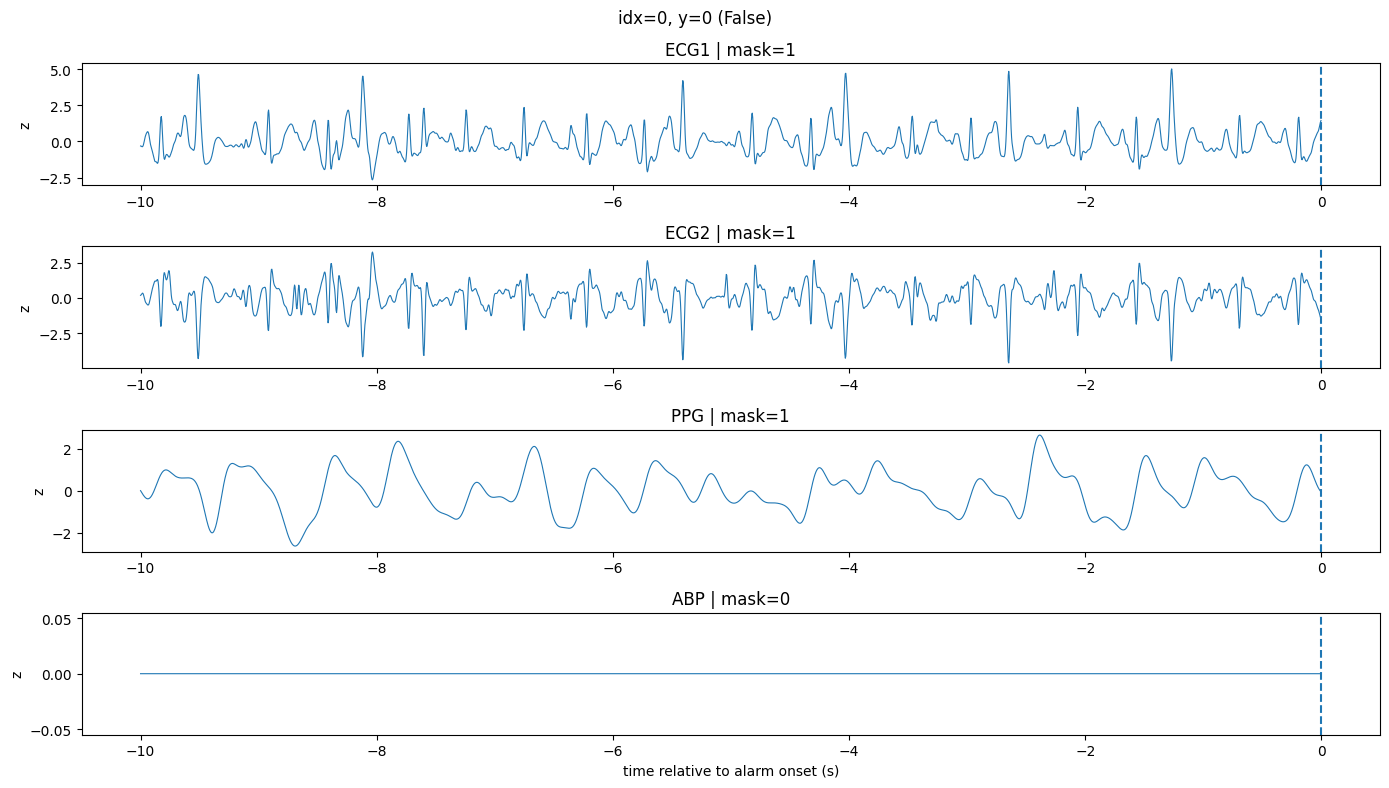

In [17]:
import matplotlib.pyplot as plt

def plot_sample(data, idx=0):
    X = data["X"][idx].numpy()
    y = int(data["y"][idx])
    m = data["m_channel"][idx].numpy()

    t = np.arange(X.shape[1]) / FS_TARGET - 10.0

    plt.figure(figsize=(14, 8))

    for i, ch in enumerate(CHANNELS_OUT):
        plt.subplot(4, 1, i + 1)
        plt.plot(t, X[i], linewidth=0.8)
        plt.axvline(0, linestyle="--")
        plt.title(f"{ch} | mask={int(m[i])}")
        plt.ylabel("z")

    plt.xlabel("time relative to alarm onset (s)")
    plt.suptitle(f"idx={idx}, y={y} ({'True' if y == 1 else 'False'})")
    plt.tight_layout()
    plt.show()


plot_sample(train_data, idx=0)